В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
!pip install opendatasets --upgrade --quiet

In [2]:
import opendatasets as od
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from google.colab import drive

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression,
    Lasso,
    Ridge,
    ElasticNet
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    mean_squared_error,
    r2_score
)


pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [3]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-3/data'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kyryloperov
Your Kaggle Key: ··········


100%|██████████| 637k/637k [00:00<00:00, 637MB/s]


Extracting archive ./bank-customer-churn-prediction-dlu-course-c-3/bank-customer-churn-prediction-dlu-course-c-3.zip to ./bank-customer-churn-prediction-dlu-course-c-3


In [4]:
data_dir = './bank-customer-churn-prediction-dlu-course-c-3'
train_csv = data_dir + '/train.csv'
test_csv =  data_dir + '/test.csv'
sample_submission_csv =  data_dir + '/sample_submission.csv'

raw_df = pd.read_csv(train_csv, index_col='id')
raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.00,Nwankwo,678.00,France,Male,29.00,4.00,0.00,3.00,1.00,0.00,180626.36,0.00
1,15650086.00,Ch'in,687.00,France,Female,34.00,1.00,0.00,2.00,0.00,1.00,63736.17,0.00
2,15733602.00,Thompson,682.00,France,Female,52.00,6.00,0.00,3.00,0.00,0.00,179655.87,1.00
3,15645794.00,Macleod,753.00,Germany,Male,44.00,6.00,83347.25,2.00,1.00,0.00,161407.48,0.00
4,15633840.00,Hsia,544.00,Germany,Female,55.00,0.00,107747.57,1.00,1.00,0.00,176580.86,1.00


Area under ROC score on Train dataset: 88.27%


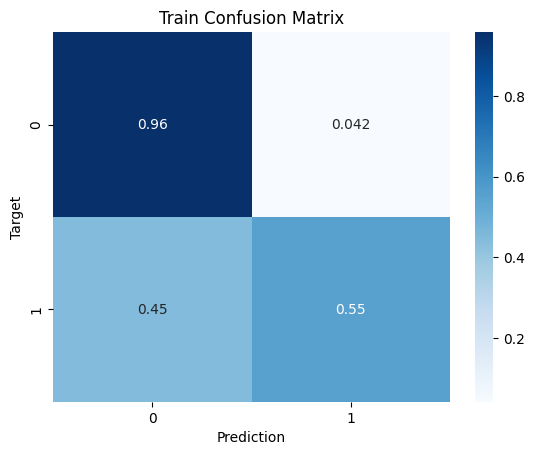

Area under ROC score on Validation dataset: 88.00%


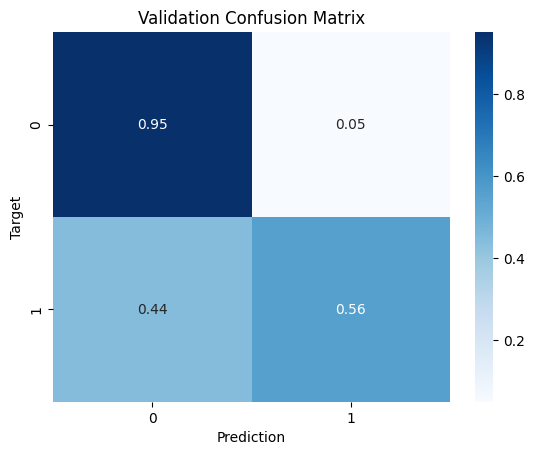

['churn_prediction_log_reg.joblib']

In [5]:
# Create training, validation sets
train_df, val_df = train_test_split(raw_df, test_size=0.25, random_state=42, stratify=raw_df['Exited'])

# Create inputs and targets
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Identify numeric and categorical columns
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
categorical_cols.remove('Surname')

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline that includes preprocessing and the model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='saga', max_iter=500))
])

# Train the model
model_pipeline.fit(train_inputs, train_targets)

# Helper function to predict & compute metrics
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    preds =  model_pipeline.predict(inputs)

    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {100*roc_auc:.2f}%")

    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Evaluate on train and validation sets
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# save the model
joblib.dump(model_pipeline, 'churn_prediction_log_reg.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

In [6]:
def create_and_train_poly_pipeline(train_inputs, train_targets, numeric_cols, categorical_cols, degree=2):

    numeric_transformer_poly = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('polynomial_features', PolynomialFeatures(degree=degree))
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_poly, numeric_cols),
            ('cat', categorical_transformer, categorical_cols)
        ])

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(solver='saga', max_iter=2000))
    ])

    model_pipeline.fit(train_inputs, train_targets)

    return model_pipeline

In [7]:
model_poly2 = create_and_train_poly_pipeline(train_inputs, train_targets, numeric_cols, categorical_cols, degree=2)

Area under ROC score on Train dataset: 93.09%


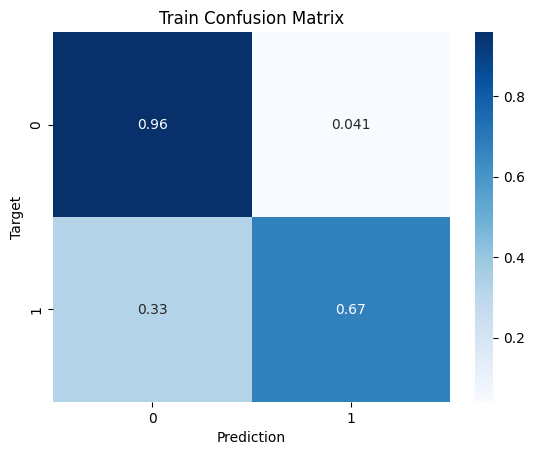

Area under ROC score on Validation dataset: 92.87%


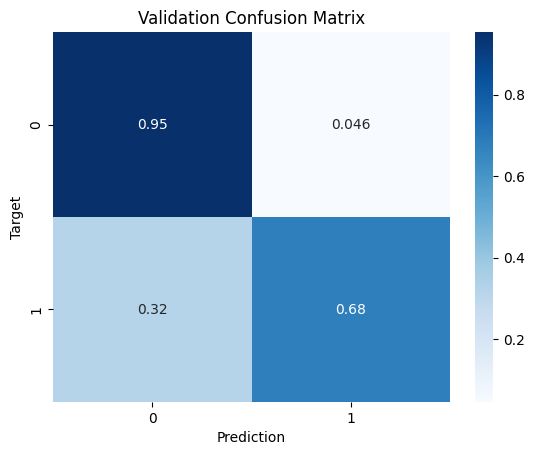

In [8]:
train_preds_poly2 = predict_and_plot(model_poly2, train_inputs, train_targets, name='Train')
val_preds_poly2 = predict_and_plot(model_poly2, val_inputs, val_targets, name='Validation')

**Спостереження:**

- Модель показує однаково високий Area under ROC (~93%) на тренувальних і валідаційних даних.
- Сonfusion matrix свідчить про доволі схожу якість класифікації.

**Висновок:**

Це означає, що модель не має ознак ні overfit, ні underfit і добре генералізує.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

In [9]:
model_poly4 = create_and_train_poly_pipeline(train_inputs, train_targets, numeric_cols, categorical_cols, degree=4)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Area under ROC score on Train dataset: 94.24%


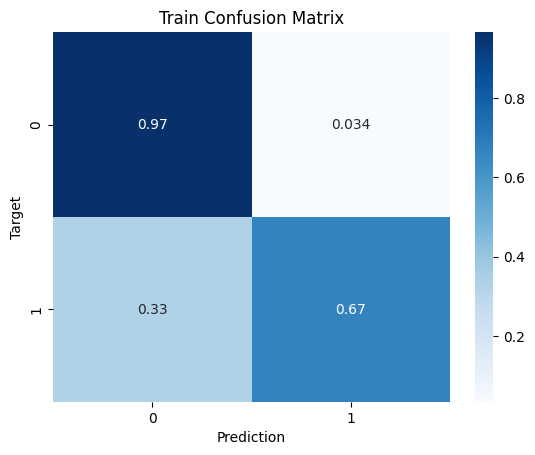

Area under ROC score on Validation dataset: 92.32%


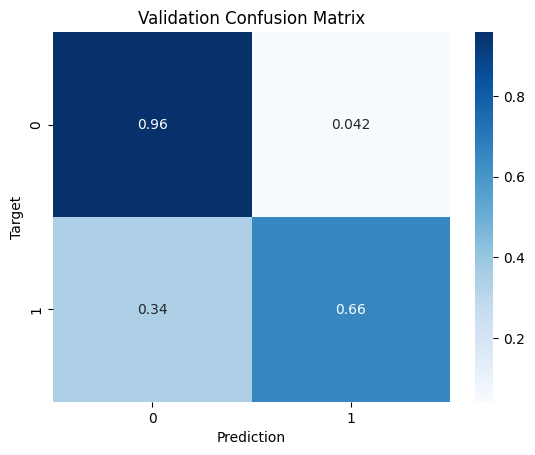

In [10]:
train_preds_poly4 = predict_and_plot(model_poly4, train_inputs, train_targets, name='Train')
val_preds_poly4 = predict_and_plot(model_poly4, val_inputs, val_targets, name='Validation')

**Спостереження:**

- Модель показує більш високий Area under ROC (94.46%) на тренувальних і менший (92.34%) на валідаційних даних - Але все одно різниця не така значна (2.1%)
- Сonfusion matrix свідчить про доволі схожу якість класифікації.

**Висновок:**

Це означає, що модель не має **виражених** ознак ні overfit (але початкові ознаки присутні), ні underfit і добре генералізує.

In [11]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(model_pipeline, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    inputs = input_df[numeric_cols + categorical_cols]
    proba = model_pipeline.predict_proba(inputs)[:,1]
    return proba

In [12]:
test_raw_df = pd.read_csv(test_csv,index_col='id')

exited_predicts = predict_raw_df(model_poly2, numeric_cols, categorical_cols, test_raw_df)
test_raw_df['Exited'] = exited_predicts

sample_submission_df = pd.read_csv(sample_submission_csv, index_col='id')
sample_submission_df['Exited'] = exited_predicts
sample_submission_df.head()

,Exited
id,
15000,0.09
15001,0.02
15002,0.07
15003,0.37
15004,0.03


In [13]:
sample_submission_df.to_csv('submission_log_reg.csv')

Ще спробував натренувати з degree=3. Там вийшов більш стабільний результат - його засабмітив до кагглу.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [14]:
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
reg_df = pd.read_csv("/content/drive/MyDrive/ML/MLFH 3.0/data/regression/regression_data.csv")
reg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  129 non-null    float64
 1   feature_2  129 non-null    float64
 2   feature_3  129 non-null    float64
 3   feature_4  129 non-null    float64
 4   feature_5  129 non-null    float64
 5   target     129 non-null    float64
dtypes: float64(6)
memory usage: 6.2 KB


In [16]:
reg_df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,129.00,129.00,129.00,129.00,129.00,129.00
mean,-0.08,-0.02,0.09,-0.08,0.05,-3.90
std,0.94,1.07,0.98,0.91,1.00,45.47
min,-3.24,-2.62,-1.91,-2.21,-2.30,-111.75
25%,-0.70,-0.76,-0.55,-0.73,-0.77,-37.34
50%,-0.07,-0.16,0.12,0.02,0.01,-0.64
75%,0.53,0.68,0.62,0.52,0.79,25.46
max,2.12,3.85,3.08,2.31,2.08,115.13


In [17]:
reg_train_df, reg_test_df = train_test_split(reg_df, test_size=0.2, random_state=42)

reg_input_cols = list(reg_train_df.columns)[:-1]
reg_target_col = 'target'
reg_train_inputs, reg_train_targets = reg_train_df[reg_input_cols].copy(), reg_train_df[reg_target_col].copy()
reg_test_inputs, reg_test_targets = reg_test_df[reg_input_cols].copy(), reg_test_df[reg_target_col].copy()

numeric_transformer_poly = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('polynomial_features', PolynomialFeatures(degree=5))
    ])

preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_poly, reg_input_cols)
        ])

reg_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])

reg_model.fit(reg_train_inputs, reg_train_targets)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('polynomial_features',
                                                                   PolynomialFeatures(degree=5))]),
                                                  ['feature_1', 'feature_2',
                                                   'feature_3', 'feature_4',
                                                   'feature_5'])])),
                ('regressor', LinearRegression())])

In [31]:
def evaluate_model_with_plot(model, train_inputs, train_targets, test_inputs, test_targets):
    train_targets_pred = model.predict(train_inputs)
    test_targets_pred = model.predict(test_inputs)

    loss_train = np.sqrt(mean_squared_error(train_targets, train_targets_pred))
    loss_test = np.sqrt(mean_squared_error(test_targets, test_targets_pred))
    r2_train = r2_score(train_targets, train_targets_pred)
    r2_test = r2_score(test_targets, test_targets_pred)

    print(f"Train set: RMSE = {loss_train:.3f}    R-squared = {r2_train:.3f}")
    print(f"Test  set: RMSE = {loss_test:.3f}    R-squared = {r2_test:.3f}")

    plt.figure(figsize=(10, 7))
    plt.scatter(train_targets, train_targets_pred, color='blue', alpha=0.5, label='Train set')
    plt.scatter(test_targets, test_targets_pred, color='green', alpha=0.7, label='Test set')

    min_val = min(train_targets.min(), test_targets.min())
    max_val = max(train_targets.max(), test_targets.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.title('Actual vs. Predicted')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.legend()
    plt.grid(True)
    plt.show()

    return dict(train=round(loss_train, 3), test=round(loss_test, 3))

Train set: RMSE = 0.000    R-squared = 1.000
Test  set: RMSE = 35.628    R-squared = 0.456


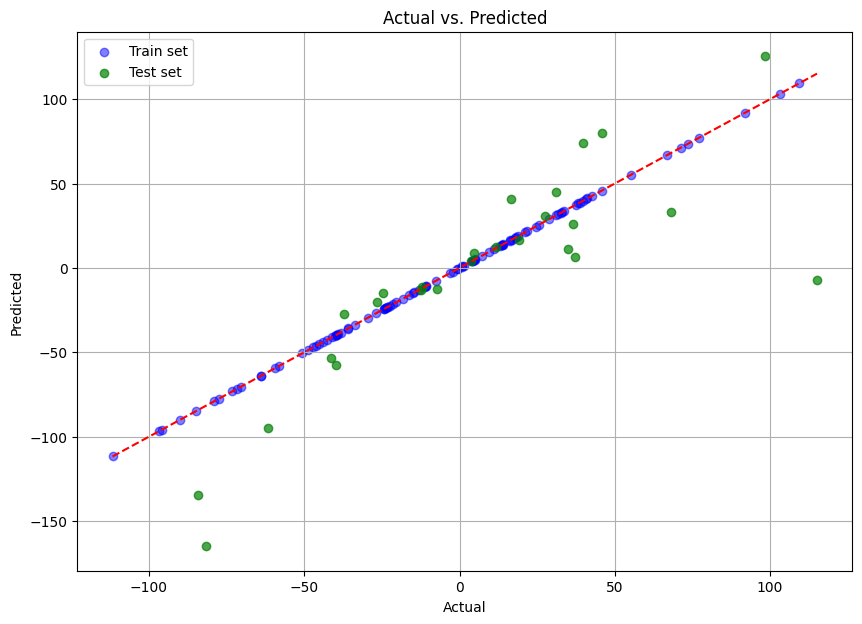

In [32]:
eval_results_lin = evaluate_model_with_plot(reg_model, reg_train_inputs, reg_train_targets, reg_test_inputs, reg_test_targets)

**Спостереження:**

- З нульовим RMSE та максимальним R2 на тренувальних даних і значно гіршими показниками на тестових даних ця модель ідеально описує тренувальні дані, але на тестових працює гірше.

**Висновок:**

Модель має ознаки перенавченості (overfit)

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [29]:
def create_and_train_pipeline(regressor, degree=20):

    numeric_transformer = Pipeline(steps=[
        ('polynomial_features', PolynomialFeatures(degree=degree)),
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, reg_input_cols),
    ])

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])

    model_pipeline.fit(reg_train_inputs, reg_train_targets)
    return model_pipeline

def evaluate_model(model, train_inputs, train_targets, test_inputs, test_targets):
    train_targets_pred = model.predict(train_inputs)
    test_targets_pred = model.predict(test_inputs)

    loss_train = np.sqrt(mean_squared_error(train_targets, train_targets_pred))
    loss_test = np.sqrt(mean_squared_error(test_targets, test_targets_pred))

    return dict(train=round(loss_train, 3), test=round(loss_test, 3))

In [33]:
models = [
    Lasso(),
    Ridge(),
    ElasticNet()
]

print(f'LinearRegression(): {eval_results_lin}\n')

for model in models:
    model_pipeline = create_and_train_pipeline(model)
    eval_results  = evaluate_model(model_pipeline, reg_train_inputs, reg_train_targets, reg_test_inputs, reg_test_targets)
    print(f'{str(model)}: {eval_results}\n')


LinearRegression(): {'train': np.float64(0.0), 'test': np.float64(35.628)}

Lasso(): {'train': np.float64(1.479), 'test': np.float64(1.392)}

Ridge(): {'train': np.float64(1.054), 'test': np.float64(27.798)}

ElasticNet(): {'train': np.float64(12.044), 'test': np.float64(20.624)}



**Спостереження:**

- LinearRegression(degree=5): RMSE = 0.00 (Train) та 35.6 (Test) — яскраве перенавчання, адже на тренуванні помилка нульова, а на тесті досить велика.

- Ridge(): RMSE ≈ 1.05 (Train) та 27.80 (Test) — теж сильне перенавчання;

- ElasticNet(): RMSE ≈ 12.04 (Train) та 20.62 (Test) — немає ознак сильного перенавчання, проте якість загалом нижча.

- Lasso(): RMSE ≈ 1.48 (Train) та 1.39 (Test) — найкраще узагальнює, оскільки різниця між тренувальним і тестовим результатом мінімальна.

Lasso-регресія чудово генералізує, незважаючи на величезну кількість поліноміальних ознак, згенерованих PolynomialFeatures(degree=20). Це є однією з ключових переваг Lasso завдяки її L1-регуляризації (зануляти коефіцієнти менш важливих ознак).

In [39]:
model_lasso = Lasso()
model_pipeline = create_and_train_pipeline(model_lasso)

poly = model_pipeline['preprocessor'].named_transformers_['num'].named_steps['polynomial_features']
feature_names = poly.get_feature_names_out(reg_train_inputs.columns)

coefs = model_pipeline['regressor'].coef_
coefs_df = pd.DataFrame({
    'feature_name': feature_names,
    'value': coefs.round(3)
})

coefs_df.shape

(53130, 2)

In [40]:
coefs_df['abs_value'] = coefs_df['value'].abs()

coefs_df_sorted = coefs_df.set_index('feature_name').sort_values(by='abs_value', ascending=False)

display(coefs_df_sorted.head(10).style.background_gradient(cmap='Blues'))

,value,abs_value
feature_name,,
feature_4,43.121000,43.121000
feature_1^7 feature_3^5 feature_4 feature_5^6,-0.000000,0.000000
feature_1^7 feature_3^5 feature_5^7,-0.000000,0.000000
feature_1^7 feature_3^4 feature_4^8,-0.000000,0.000000
feature_1^7 feature_3^4 feature_4^7 feature_5,0.000000,0.000000
feature_1^7 feature_3^4 feature_4^6 feature_5^2,-0.000000,0.000000
feature_1^7 feature_3^4 feature_4^5 feature_5^3,0.000000,0.000000
feature_1^7 feature_3^4 feature_4^4 feature_5^4,-0.000000,0.000000
feature_1^7 feature_3^4 feature_4^3 feature_5^5,0.000000,0.000000


**Спостереження:**

- з усіх 53130 різних фічей так їх комбінацій по модулю значиме значення тільки у колонки feature_4

**Висновок:**
- Це означає, що модель фактично використовує переважно одну ключову фічу (чи її похідні) і відсікає решту, сприймаючи їх як менш релевантні або зайві.